In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
train_data = datasets.CIFAR10(
    root = 'data',
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data = datasets.CIFAR10(
    root = 'data',
    train = False,
    download=True,
    transform=ToTensor(),
)

In [3]:
train_data[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [4]:
image,label = train_data[0]

In [5]:
image

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [6]:
label

6

In [7]:
image.shape

torch.Size([3, 32, 32])

In [8]:
len(train_data)

50000

In [9]:
len(test_data)

10000

In [10]:
class_names = train_data.classes

In [11]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [12]:
len(class_names)

10

### PyTorch görselleri [Kanal, Yükseklik, Genişlik] (3, 32, 32) formatında tutar.
### Matplotlib ise ekrana çizdirirken [Yükseklik, Genişlik, Kanal] (32, 32, 3) formatını bekler.
### permute(1, 2, 0) ile boyut indekslerinin sırası değiştirilerek tensor Matplotlib'in formatına dönüştürülür:
### 0. indeksteki Kanal -> en sona (2)
### 1. indeksteki Yükseklik -> başa (0)
### 2. indeksteki Genişlik -> ortaya (1)

Text(0.5, 1.0, 'truck')

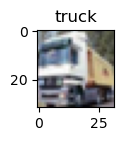

In [14]:
image, label = train_data[1]
image = image.permute(1, 2, 0)
plt.figure(figsize=(1,1))
plt.imshow(image)
plt.title(class_names[label])

In [15]:
from torchvision import transforms

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(), # Görseli [0, 1] aralığında Tensor'a çevirir
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )])

# transforms.Compose([
#     transforms.ToTensor(),   # 1. Önce PIL -> Tensor'a çevirir ve [0, 255] -> [0.0, 1.0] yapar
#     transforms.Normalize(...) # 2. Sonra [0.0, 1.0] arasındaki Tensor'ı normalize eder
# ])

In [17]:
train_data = datasets.CIFAR10(
    root = 'data',
    train=True,
    download=True,
    transform=transform,
    target_transform=None
)
test_data = datasets.CIFAR10(
    root = 'data',
    train = False,
    download=True,
    transform=transform,
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9100897..2.100835].


Text(0.5, 1.0, 'truck')

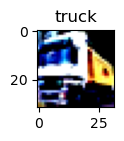

In [18]:
image, label = train_data[1]
image = image.permute(1, 2, 0)
plt.figure(figsize=(1,1))
plt.imshow(image)
plt.title(class_names[label])

In [19]:
# dataloader -> training e hazirlama asamasi

In [20]:
from torch.utils.data import DataLoader

In [21]:
BATCH_SIZE = 32 # 32 & 128
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False) # test datayi shuffle etmeye gerek yok zaten model egitilmis oluyor.

In [22]:
len(train_dataloader),len(test_dataloader)

(1563, 313)

In [23]:
test_dataloader.dataset[0][0].shape

torch.Size([3, 32, 32])

In [51]:
flatten_model = nn.Flatten()

first_data = train_dataloader.dataset[0][0]
flattened_data = flatten_model(first_data)

print(first_data.shape)
print(flattened_data.shape)

torch.Size([3, 32, 32])
torch.Size([3, 1024])


In [57]:
class CIFAR10Classifier(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )

    def forward(self, x):
        return self.layer_stack(x)

In [59]:
first_data.shape

torch.Size([3, 32, 32])

In [61]:
3*32*32 # input features

3072

In [65]:
len(class_names) # output features

10

In [67]:
torch.manual_seed(42)

model_0 = CIFAR10Classifier(
    input_shape= 3*32*32,
    hidden_units=32,
    output_shape=len(class_names)
)

In [69]:
model_0 = torch.compile(model_0)
loss_fn = nn.CrossEntropyLoss() # 1'den fazla sinif oldugu icin
optimizer = torch.optim.Adam(params=model_0.parameters() ,lr=0.01)

In [71]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() 
    acc = (correct / len(y_pred)) * 100 
    return acc

In [77]:
# training
torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    train_loss = 0

    for batch, (X,y) in enumerate(train_dataloader):
        y_pred = model_0(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 == 0:
            print(f'Batch Number: {batch}')

    train_loss /= len(train_dataloader)

    test_loss = 0
    test_acc = 0

    model_0.eval()
    with torch.inference_mode():
        for (X,y) in test_dataloader:
            test_pred = model_0(X)
            test_loss += loss_fn(test_pred,y)
            test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))
            
        test_loss/=len(test_dataloader)
        test_acc/=len(test_dataloader)
        
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500

Train loss: 2.50445 | Test loss: 2.49511, Test acc: 28.11%

Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500

Train loss: 2.51082 | Test loss: 2.40035, Test acc: 29.39%

Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500

Train loss: 2.52627 | Test loss: 2.51858, Test acc: 28.67%

Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500

Train loss: 2.53252 | Test loss: 2.48562, Test acc: 26.38%

Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500

Train loss: 2.52060 | Test loss: 2.48341, Test acc: 26.91%

Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500

Train loss: 2.52390 | Test loss: 2.53699, Test acc: 27.14%

Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500

Train loss: 2.50490 | Test loss: 2.78848, Test acc: 25.42%

Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 15

In [79]:
def evaluate_model_performance(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, accuracy_function):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_function(y_true=y, y_pred=y_pred.argmax(dim=1)) 

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

In [81]:
model_0_results = evaluate_model_performance(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_function=calculate_accuracy)

In [83]:
model_0_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.6172008514404297,
 'model_acc': 26.277955271565496}

In [85]:
class CIFAR10ClassifierNonLinear(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [87]:
torch.manual_seed(42)
model_1 = CIFAR10ClassifierNonLinear(input_shape=3072, 
    hidden_units=32,
    output_shape=len(class_names) 
)

In [89]:
model_1 = torch.compile(model_1)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.01)

In [91]:
torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_1.train() 
        # 1. Forward pass
        y_pred = model_1(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch 

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print out how many samples have been seen
        if batch % 500 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)
    
    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy 
    test_loss, test_acc = 0, 0 
    model_1.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_1(X)
           
            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))
        
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 2.34545 | Test loss: 2.38594, Test acc: 28.51%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 2.30899 | Test loss: 2.28065, Test acc: 30.53%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 2.25259 | Test loss: 2.27756, Test acc: 30.14%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 2.21947 | Test loss: 2.13890, Test acc: 30.51%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 2.16992 | Test loss: 2.19811, Test acc: 27.40%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

In [92]:
model_1_results = evaluate_model_performance(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_function=calculate_accuracy)

In [97]:
model_0_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.6172008514404297,
 'model_acc': 26.277955271565496}

In [93]:
model_1_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.106597661972046,
 'model_acc': 29.812300319488816}